# YOLO Leave-One-Out Fold Training with Freeze Experiment

## Purpose

This notebook trains and evaluates YOLO models using a leave-one-out/k-fold style on the IronHorse data set.

The dataset being used is separated by video folder.

Experiments with freezing layers of the YOLO model were made to see if performance improves


## Important note

The `freeze` setting is currently commented out in the training cell:
```python
#freeze = 10
```
In this state the notebook trains YOLO normally with no freezing. To freeze layers add the line above back in.

#What this notebook does
1. Mounts Google Drive
2. Extracts the separated dataset
3. Creates leave-one-out folds
4. Creates YOLO folder structures for each fold and writes data.yaml file for each fold
5. Trains a YOLO model for each fold
6. Optionally Supports freeze training
7. Validates trained fold models, by printing metrics for each fold, plotting training metrics, displays confusion matrices
8. Creates ground-truth-versus-predictions review images
9. Zips review images for download to local system

#How to use this notebook
1. Make sure the separated dataset ZIP file is saved in Google Drive
2. Check or update the dataset ZIP path:
```python
zip_path = "/content/drive/MyDrive/SeparatedDataSet.zip"
```
3. Run the setup cells to:

mount Google drive
extract data set
find video folders
create one fold per video and write a data.yaml file for each fold

4. Run the YOLO training loop to train one model per fold
5. If you want to test freezing training, update the setting inside model.train()
6. After training review each fold by checking the model path and fold YAML file:
```python
model = YOLO("/content/yolo_folds/fold_Video 011/weights/best.pt")
metrics = model.val(data="/content/folds/fold_Video 011/data.yaml")
```

7. Review the printed evaluation metrics
8. plot each fold's training metrics
9. Display the confusion matrix for each fold
10. Create a folder of all images where the model predicted, that contains bounding boxes.
11. Create a ZIP file to download to a local system

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/SeparatedDataSet.zip"

extract_dir = "/content/dataset_raw"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extracted to:", extract_dir)
print("Top-level contents:", os.listdir(extract_dir)[:10])

Extracted to: /content/dataset_raw
Top-level contents: ['Video 012', 'video 0', 'Video 011', 'Video 014']


In [ ]:
from pathlib import Path
import shutil
import yaml

SOURCE_ROOT = Path("/content/dataset_raw")
OUTPUT_ROOT = Path("/content//folds")

CLASS_NAMES = ["unhealthly_leaf"]
COPY_FILES = True  # True = copy files, False = symlink files

# =========================
# Helper functions
# =========================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_video_folders(source_root):
    """Return subfolders that contain train/images and train/labels."""
    video_folders = []

    for folder in sorted(source_root.iterdir()):
        if not folder.is_dir():
            continue

        img_dir = folder / "train" / "images"
        lbl_dir = folder / "train" / "labels"

        if img_dir.exists() and lbl_dir.exists():
            video_folders.append(folder)

    return video_folders


def link_or_copy(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists():
        return

    if COPY_FILES:
        shutil.copy2(src, dst)
    else:
        dst.symlink_to(src)


def add_video_to_split(video_folder, fold_root, split):
    """
    Adds one video's images and labels to a YOLO split.
    split should be 'train' or 'val'.
    """
    src_img_dir = video_folder / "train" / "images"
    src_lbl_dir = video_folder / "train" / "labels"

    dst_img_dir = fold_root / "images" / split
    dst_lbl_dir = fold_root / "labels" / split

    for img_path in sorted(src_img_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue

        # Prefix filenames with video folder name to avoid duplicate names across videos
        new_img_name = f"{video_folder.name}_{img_path.name}"
        dst_img_path = dst_img_dir / new_img_name

        link_or_copy(img_path, dst_img_path)

        # YOLO label should have same stem as image, with .txt extension
        src_label_path = src_lbl_dir / f"{img_path.stem}.txt"
        new_label_name = f"{video_folder.name}_{img_path.stem}.txt"
        dst_label_path = dst_lbl_dir / new_label_name

        if src_label_path.exists():
            link_or_copy(src_label_path, dst_label_path)
        else:
            # Optional: create empty label file for images with no objects
            dst_label_path.parent.mkdir(parents=True, exist_ok=True)
            dst_label_path.touch()


def write_data_yaml(fold_root, class_names):
    data = {
        "path": str(fold_root),
        "train": "images/train",
        "val": "images/val",
        "names": {i: name for i, name in enumerate(class_names)}
    }

    with open(fold_root / "data.yaml", "w") as f:
        yaml.safe_dump(data, f, sort_keys=False)


# =========================
# Main leave-one-out split
# =========================
video_folders = get_video_folders(SOURCE_ROOT)

print(f"Found {len(video_folders)} video folders:")
for v in video_folders:
    print(" -", v.name)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

for val_video in video_folders:
    fold_root = OUTPUT_ROOT / f"fold_{val_video.name}"

    print(f"\nCreating fold: {fold_root.name}")
    print(f"Validation video: {val_video.name}")

    # Optional: remove old fold before recreating
    if fold_root.exists():
        shutil.rmtree(fold_root)

    # Create train/val folders
    for split in ["train", "val"]:
        (fold_root / "images" / split).mkdir(parents=True, exist_ok=True)
        (fold_root / "labels" / split).mkdir(parents=True, exist_ok=True)

    # Add videos
    for video in video_folders:
        if video == val_video:
            add_video_to_split(video, fold_root, "val")
        else:
            add_video_to_split(video, fold_root, "train")

    write_data_yaml(fold_root, CLASS_NAMES)


Found 4 video folders:
 - Video 011
 - Video 012
 - Video 014
 - video 0

Creating fold: fold_Video 011
Validation video: Video 011

Creating fold: fold_Video 012
Validation video: Video 012

Creating fold: fold_Video 014
Validation video: Video 014

Creating fold: fold_video 0
Validation video: video 0


In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
from pathlib import Path

folds_root = Path("/content/folds")
results_root = "/content/yolo_folds/"

for fold_root in sorted(folds_root.iterdir()):
    if not fold_root.is_dir():
        continue

    data_yaml = fold_root / "data.yaml"

    if not data_yaml.exists():
        print(f"Skipping {fold_root.name}: no data.yaml found")
        continue

    print(f"\nTraining fold: {fold_root.name}")

    # Fresh model for each fold
    model = YOLO("yolov8s.pt")

    model.train(
        data=str(data_yaml),
        epochs=100,
        patience=25,
        imgsz=1280,
        batch=16,
        #freeze = 10,
        #lr0 = 0.001,
        #weight_decay = 0.005,
        project=results_root,
        name=fold_root.name,
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Training fold: fold_Video 011
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/folds/fold_Video 011/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exi

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
from pathlib import Path

#model = YOLO("/content/yolo_folds/fold_Video 011/weights/best.pt")
model = YOLO("/content/best.pt")
metrics = model.val(data="/content/folds/fold_Video 011/data.yaml")

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3185.0±826.1 MB/s, size: 484.6 KB)
val: Scanning /content/folds/fold_Video 011/labels/val... 14 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 14/14 269.7it/s 0.1s
val: New cache created: /content/folds/fold_Video 011/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5s/it 1.5s
                   

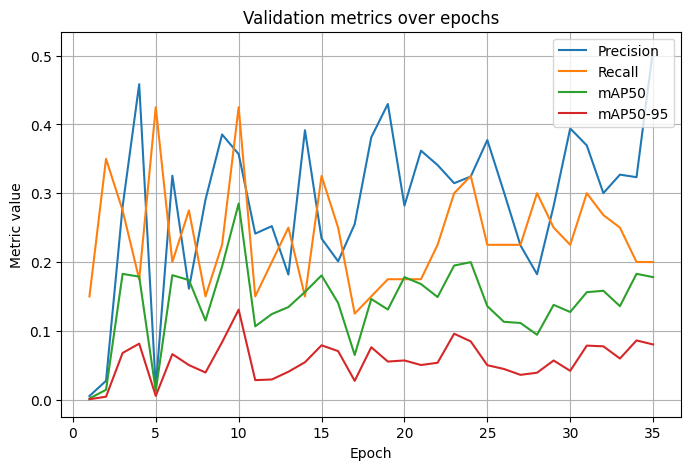

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/yolo_folds/fold_Video 011/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

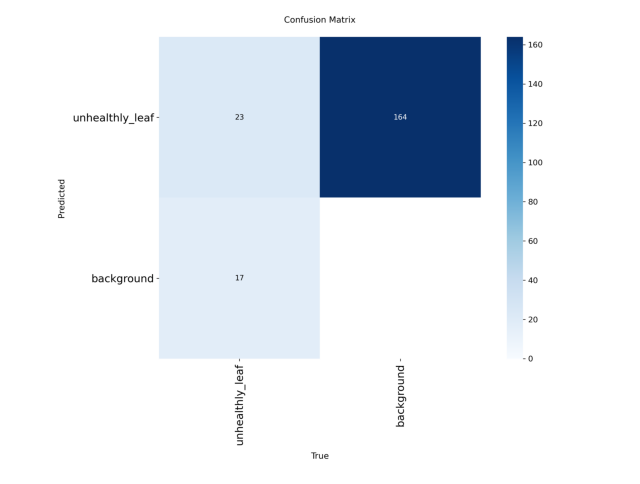

In [ ]:
from PIL import Image

img = Image.open("/content/yolo_folds/fold_Video 011/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import cv2
from pathlib import Path
import os

#model_path = "/content/yolo_folds/fold_Video 011/weights/best.pt"   # change if needed
model_path = "/content/best.pt"
dataset_root = Path("/content/folds/fold_Video 011")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video011")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (0, 255, 255)    # green

# prediction settings
CONF_THRES = 0.30
IOU_THRES = 0.30

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 227 images from /content/folds/fold_Video 011/images/train
Saved outputs to /content/gt_vs_pred_fold_Video011/train
Processing 14 images from /content/folds/fold_Video 011/images/val
Saved outputs to /content/gt_vs_pred_fold_Video011/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video011


In [ ]:
import shutil

review_dir = "/content/gt_vs_pred_fold_Video011"
zip_base = "/content/gt_vs_pred_fold_Video011"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video011.zip


In [ ]:
model = YOLO("/content/yolo_folds/fold_Video 012/weights/best.pt")
metrics = model.val(data="/content/folds/fold_Video 012/data.yaml")

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3709.6±533.0 MB/s, size: 575.4 KB)
val: Scanning /content/folds/fold_Video 012/labels/val.cache... 53 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 53/53 18.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1it/s 3.6s
                   all         53        130      0.513      0.415      0.377      0.127
Speed: 10.1ms preprocess, 14.1ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val-2
Fold_2metrics
Precision: 0.5125148211410365
Recall: 0.4153846153846154
mAP50: 0.3771122877617236
mAP50-95: 0.12740811129445054


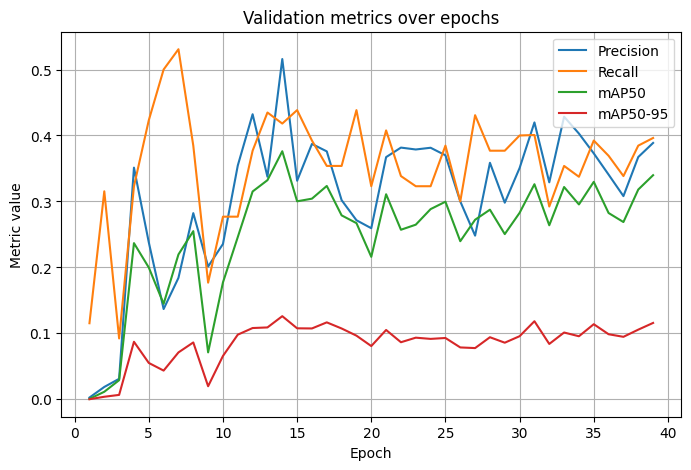

In [ ]:
df = pd.read_csv("/content/yolo_folds/fold_Video 012/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

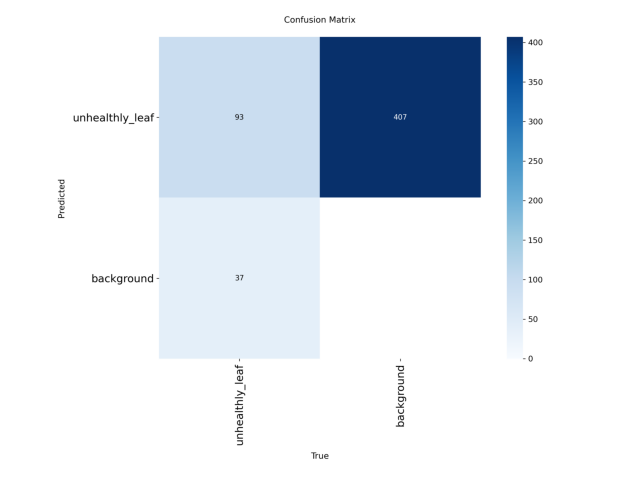

In [ ]:
img = Image.open("/content/yolo_folds/fold_Video 012/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
#model_path = "/content/yolo_folds/fold_Video 012/weights/best.pt"   # change if needed
model_path = "/content/best.pt"
dataset_root = Path("/content/folds/fold_Video 012")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video012")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (0, 255, 255)    # yellow
# prediction settings
CONF_THRES = 0.30
IOU_THRES = 0.30

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 188 images from /content/folds/fold_Video 012/images/train
Saved outputs to /content/gt_vs_pred_fold_Video012/train
Processing 53 images from /content/folds/fold_Video 012/images/val
Saved outputs to /content/gt_vs_pred_fold_Video012/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video012


In [ ]:
review_dir = "/content/gt_vs_pred_fold_Video012"
zip_base = "/content/gt_vs_pred_fold_Video012"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video012.zip


In [ ]:
model = YOLO("/content/yolo_folds/fold_Video 014/weights/best.pt")
metrics = model.val(data="/content/folds/fold_Video 014/data.yaml")

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3725.0±285.5 MB/s, size: 638.0 KB)
val: Scanning /content/folds/fold_Video 014/labels/val.cache... 45 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 18.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.0it/s 2.9s
                   all         45         96      0.397      0.427      0.336      0.126
Speed: 12.4ms preprocess, 9.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val-3
Fold_2metrics
Precision: 0.3967479112235722
Recall: 0.4270833333333333
mAP50: 0.33629634169593536
mAP50-95: 0.12575001649901088


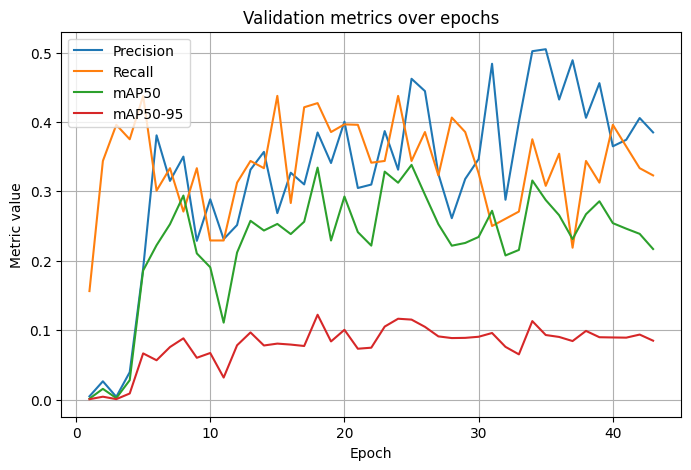

In [ ]:
df = pd.read_csv("/content/yolo_folds/fold_Video 014/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

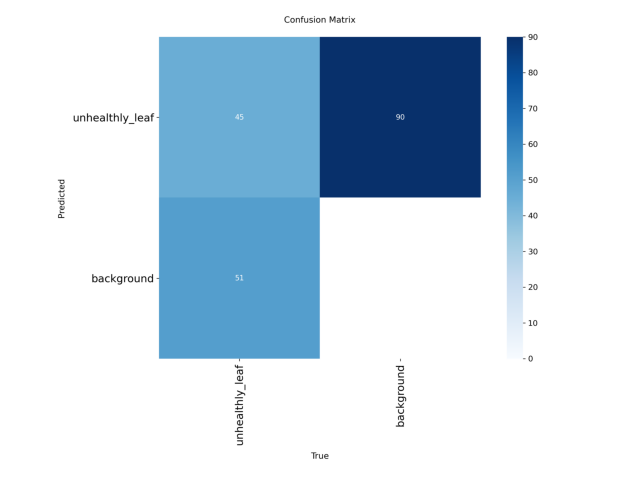

In [ ]:
img = Image.open("/content/yolo_folds/fold_Video 014/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:

#model_path = "/content/yolo_folds/fold_Video 012/weights/best.pt"   # change if needed
model_path = "/content/best.pt"
dataset_root = Path("/content/folds/fold_Video 014")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video014")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (0, 255, 255)    # yellow

# prediction settings
CONF_THRES = 0.30
IOU_THRES = 0.30

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 196 images from /content/folds/fold_Video 014/images/train
Saved outputs to /content/gt_vs_pred_fold_Video014/train
Processing 45 images from /content/folds/fold_Video 014/images/val
Saved outputs to /content/gt_vs_pred_fold_Video014/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video014


In [ ]:
review_dir = "/content/gt_vs_pred_fold_Video014"
zip_base = "/content/gt_vs_pred_fold_Video014"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video014.zip


In [ ]:
model = YOLO("/content/yolo_folds/fold_video 0/weights/best.pt")
metrics = model.val(data="/content/folds/fold_video 0/data.yaml")

print("Fold_2metrics")
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4370.9±712.2 MB/s, size: 2061.4 KB)
val: Scanning /content/folds/fold_video 0/labels/val.cache... 129 images, 29 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 45.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.2it/s 4.1s
                   all        129        288      0.224      0.215      0.132     0.0391
Speed: 4.8ms preprocess, 10.7ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val-4
Fold_2metrics
Precision: 0.22401565655548122
Recall: 0.2152777777777778
mAP50: 0.13224424884424885
mAP50-95: 0.039110037359170145


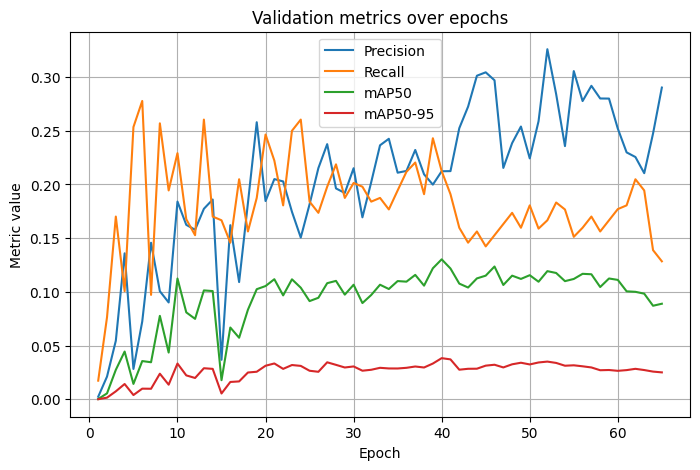

In [ ]:
df = pd.read_csv("/content/yolo_folds/fold_video 0/results.csv")
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation metrics over epochs")
plt.legend()
plt.grid(True)
plt.show()

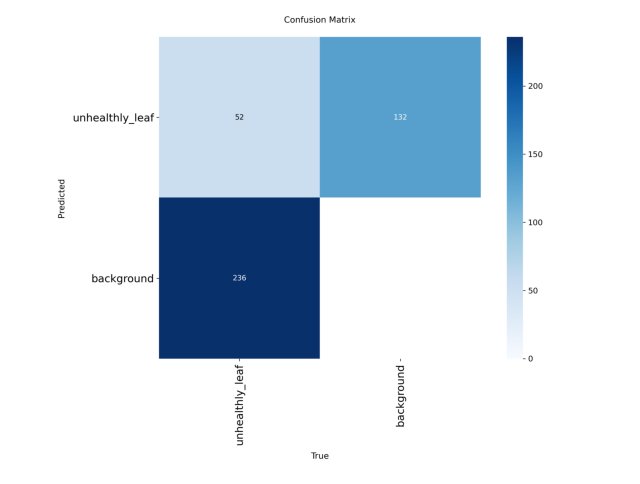

In [ ]:
img = Image.open("/content/yolo_folds/fold_video 0/confusion_matrix.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:

#model_path = "/content/yolo_folds/fold_Video 012/weights/best.pt"   # change if needed
model_path = "/content/best.pt"
dataset_root = Path("/content/folds/fold_video 0")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video0")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (0, 255, 255)    # yellow

# prediction settings
CONF_THRES = 0.30
IOU_THRES = 0.30

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 112 images from /content/folds/fold_video 0/images/train
Saved outputs to /content/gt_vs_pred_fold_Video0/train
Processing 129 images from /content/folds/fold_video 0/images/val
Saved outputs to /content/gt_vs_pred_fold_Video0/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video0


In [ ]:
review_dir = "/content/gt_vs_pred_fold_Video0"
zip_base = "/content/gt_vs_pred_fold_Video0"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video0.zip


#Visualize the images from the models

In [ ]:
import cv2
!pip install ultralytics -q

from ultralytics import YOLO


#model_path = "/content/yolo_folds/fold_Video 012/weights/best.pt"   # change if needed
model_path = "/content/best.pt"
dataset_root = Path("/content/folds/fold_Video 011")        # change if needed
output_root = Path("/content/gt_vs_pred_fold_Video11")

# image folders
train_images_dir = dataset_root / "images" / "train"
val_images_dir   = dataset_root / "images" / "val"

# label folders
train_labels_dir = dataset_root / "labels" / "train"
val_labels_dir   = dataset_root / "labels" / "val"

# output folders
(output_root / "train").mkdir(parents=True, exist_ok=True)
(output_root / "val").mkdir(parents=True, exist_ok=True)

# class names
class_names = {0: "unhealthy_leaf"}

# colors in BGR for OpenCV
GT_COLOR = (0, 0, 255)      # red
PRED_COLOR = (0, 255, 255)    # yellow

# prediction settings
CONF_THRES = 0.30
IOU_THRES = 0.30

model = YOLO(model_path)

def yolo_to_xyxy(line, img_w, img_h):
    """
    Convert YOLO label line:
    class x_center y_center width height
    (normalized)
    to pixel xyxy
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None

    cls_id = int(float(parts[0]))
    x_c = float(parts[1]) * img_w
    y_c = float(parts[2]) * img_h
    w = float(parts[3]) * img_w
    h = float(parts[4]) * img_h

    x1 = int(x_c - w / 2)
    y1 = int(y_c - h / 2)
    x2 = int(x_c + w / 2)
    y2 = int(y_c + h / 2)

    return cls_id, x1, y1, x2, y2

def draw_ground_truth(img, label_path):
    h, w = img.shape[:2]

    if not label_path.exists():
        return img

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parsed = yolo_to_xyxy(line, w, h)
        if parsed is None:
            continue

        cls_id, x1, y1, x2, y2 = parsed

        cv2.rectangle(img, (x1, y1), (x2, y2), GT_COLOR, 2)

        text = "GT"
        cv2.putText(
            img,
            text,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            GT_COLOR,
            2
        )

    return img

def draw_predictions(img, result):
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        cv2.rectangle(img, (x1, y1), (x2, y2), PRED_COLOR, 2)

        # confidence only, no class label
        text = f"{conf:.2f}"
        cv2.putText(
            img,
            text,
            (x1, min(y2 + 20, img.shape[0] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            PRED_COLOR,
            2
        )

    return img

def process_folder(images_dir, labels_dir, save_dir):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted([p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions])

    print(f"Processing {len(image_files)} images from {images_dir}")

    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        # draw ground truth first
        img = draw_ground_truth(img, label_path)

        # predict on this single image
        result = model.predict(
            source=str(img_path),
            conf=CONF_THRES,
            iou=IOU_THRES,
            save=False,
            verbose=False
        )[0]

        # draw predictions second
        img = draw_predictions(img, result)

        out_path = save_dir / img_path.name
        cv2.imwrite(str(out_path), img)

    print(f"Saved outputs to {save_dir}")

# process train and val
process_folder(train_images_dir, train_labels_dir, output_root / "train")
process_folder(val_images_dir, val_labels_dir, output_root / "val")

print(f"Done. Outputs saved under: {output_root}")

Processing 227 images from /content/folds/fold_Video 011/images/train
Saved outputs to /content/gt_vs_pred_fold_Video11/train
Processing 14 images from /content/folds/fold_Video 011/images/val
Saved outputs to /content/gt_vs_pred_fold_Video11/val
Done. Outputs saved under: /content/gt_vs_pred_fold_Video11


In [ ]:
review_dir = "/content/gt_vs_pred_fold_Video11"
zip_base = "/content/gt_vs_pred_fold_Video1"

shutil.make_archive(zip_base, "zip", review_dir)
print("Created:", zip_base + ".zip")

Created: /content/gt_vs_pred_fold_Video1.zip
